# Case Study 1: Normal Random Numbers

**Scenario:** We have a dataset of 500 measurements drawn from a normal process (mean ≈ 10, SD ≈ 2). The goal is to verify, using EDA tools, that all four fundamental assumptions hold:
1. Fixed location
2. Fixed variation
3. Independent data
4. Normal distribution

This is the *baseline* case — a well-behaved dataset where all EDA checks pass. Understanding what good looks like is essential before diagnosing problems in real data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

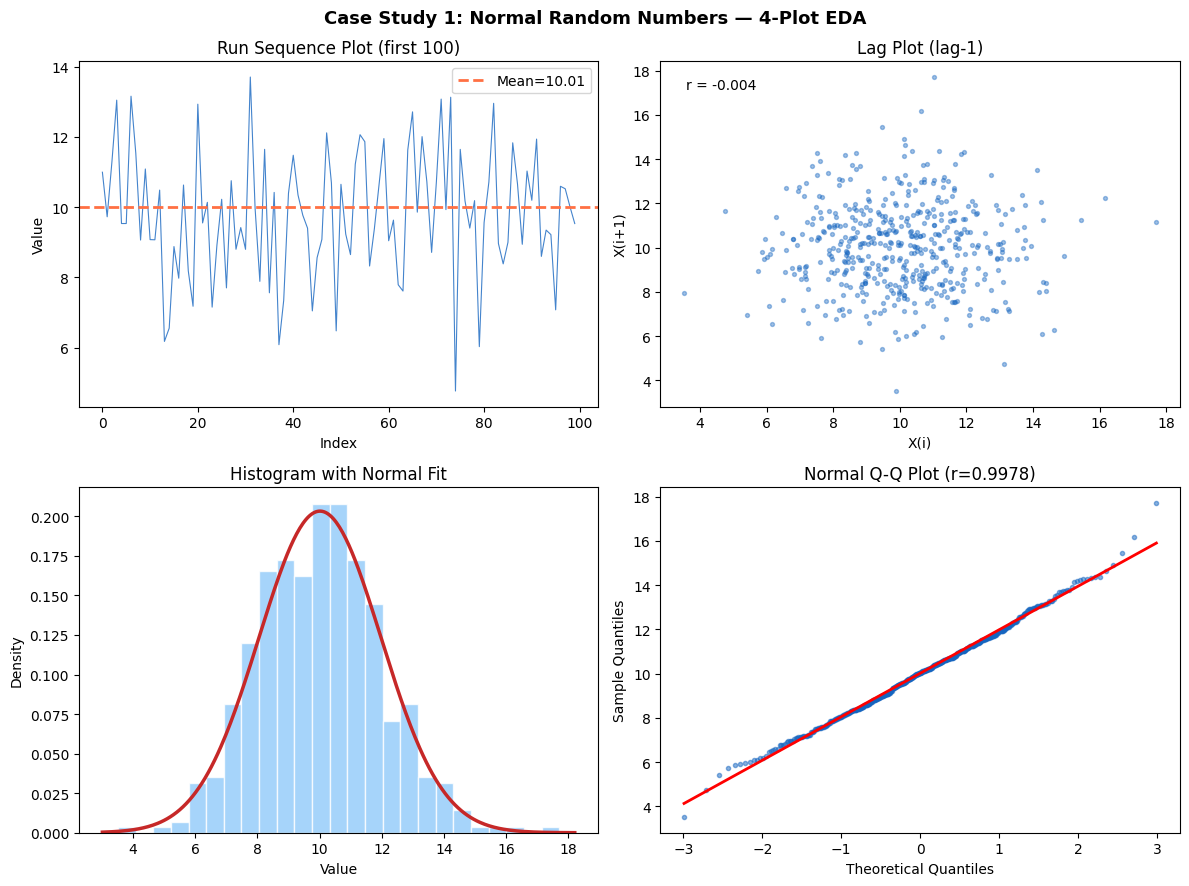

Descriptive Statistics:
  n=500, mean=10.0137, std=1.9625
  min=3.5175, max=17.7055, range=14.1880
Normality: Anderson-Darling A²=0.2978, crit(5%)=0.7810 → PASS
Location test: t-test vs μ=10, p=0.8762 → PASS (no shift)
Independence: Lag-1 correlation = -0.0040 → PASS


In [2]:
np.random.seed(42)
n = 500
data = np.random.normal(loc=10.0, scale=2.0, size=n)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Case Study 1: Normal Random Numbers — 4-Plot EDA', fontsize=13, fontweight='bold')

# Run sequence plot
axes[0,0].plot(data[:100], color='#1565C0', lw=0.8, alpha=0.8)
axes[0,0].axhline(data.mean(), color='#FF7043', lw=2, ls='--', label=f'Mean={data.mean():.2f}')
axes[0,0].set_title('Run Sequence Plot (first 100)')
axes[0,0].set_xlabel('Index'); axes[0,0].set_ylabel('Value')
axes[0,0].legend()

# Lag plot (lag-1)
axes[0,1].scatter(data[:-1], data[1:], color='#1565C0', s=8, alpha=0.4)
axes[0,1].set_title('Lag Plot (lag-1)')
axes[0,1].set_xlabel('X(i)'); axes[0,1].set_ylabel('X(i+1)')
r_lag = np.corrcoef(data[:-1], data[1:])[0, 1]
axes[0,1].text(0.05, 0.92, f'r = {r_lag:.3f}', transform=axes[0,1].transAxes, fontsize=10)

# Histogram with normal fit
axes[1,0].hist(data, bins=25, density=True, color='#90CAF9', edgecolor='white', alpha=0.8)
x = np.linspace(data.min()-0.5, data.max()+0.5, 300)
axes[1,0].plot(x, stats.norm(data.mean(), data.std(ddof=1)).pdf(x), color='#C62828', lw=2.5)
axes[1,0].set_title('Histogram with Normal Fit')
axes[1,0].set_xlabel('Value'); axes[1,0].set_ylabel('Density')

# Normal Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
axes[1,1].plot(osm, osr, 'o', color='#1565C0', ms=3, alpha=0.5)
axes[1,1].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2)
axes[1,1].set_title(f'Normal Q-Q Plot (r={r:.4f})')
axes[1,1].set_xlabel('Theoretical Quantiles'); axes[1,1].set_ylabel('Sample Quantiles')

plt.tight_layout(); plt.show()

# Quantitative checks
ad_stat, ad_crit, _ = stats.anderson(data, dist='norm')
_, sw_p = stats.shapiro(data[:200])
from scipy.stats import ttest_1samp
_, t_p = ttest_1samp(data, popmean=10.0)

print(f'Descriptive Statistics:')
print(f'  n={n}, mean={data.mean():.4f}, std={data.std(ddof=1):.4f}')
print(f'  min={data.min():.4f}, max={data.max():.4f}, range={data.max()-data.min():.4f}')
print(f'Normality: Anderson-Darling A²={ad_stat:.4f}, crit(5%)={ad_crit[2]:.4f} → {"PASS" if ad_stat<ad_crit[2] else "FAIL"}')
print(f'Location test: t-test vs μ=10, p={t_p:.4f} → {"PASS (no shift)" if t_p>0.05 else "FAIL (shift detected)"}')
lag1_r = np.corrcoef(data[:-1], data[1:])[0,1]
print(f'Independence: Lag-1 correlation = {lag1_r:.4f} → {"PASS" if abs(lag1_r)<0.1 else "FAIL"}')

## Conclusions

| Check | Result | Notes |
|---|---|---|
| **Fixed location** | ✅ Pass | Run sequence shows no trend or shift |
| **Fixed variation** | ✅ Pass | No widening or narrowing in run sequence |
| **Independence** | ✅ Pass | Lag plot is circular; lag-1 r ≈ 0 |
| **Normality** | ✅ Pass | Q-Q plot is linear; Anderson-Darling passes |

**This is the baseline.** All four assumptions hold for normally distributed random numbers. In practice, data rarely looks this clean — the goal of EDA is to identify which assumptions are violated and how severely.